In [1]:
# Import packages
import pandas as pd                 
import matplotlib.pyplot as plt     
import numpy as np                  
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import lightgbm as lgb
import shap
shap.initjs()

## 1. Data wrangling

Read the data from the source into a `pandas` data frame.

In [2]:
df_original = pd.read_csv("https://drive.google.com/uc?id=1_jYVXj7mt8Zzpjn8WGI111G-kWRTbfjU", index_col='date' , parse_dates=['date']) 
df_original.describe().T

,count,mean,std,min,25%,50%,75%,max
plant.feed.iron.comp,241920.0,56.283827,5.194494,42.740000,52.61000,56.02000,59.720000,65.780000
plant.feed.silica.comp,241920.0,14.663951,6.852066,1.310000,8.87000,13.94000,19.970000,33.400000
plant.flotation.sump01.starch.flow,241920.0,2874.416302,1203.059244,0.074147,2081.49750,3021.68500,3727.115000,6295.130657
plant.flotation.sump01.amina.flow,241920.0,488.451777,90.712968,241.699211,432.36275,504.70300,553.518000,739.412200
plant.flotation.sump01.discharge.flow,241920.0,397.543859,9.597032,376.268217,394.89500,399.31600,402.627000,418.625439
plant.flotation.sump01.discharge.ph,241920.0,9.768052,0.387234,8.753370,9.52828,9.79929,10.037700,10.808063
plant.flotation.sump01.discharge.density,241920.0,1.680243,0.068796,1.519823,1.64744,1.69734,1.727710,1.853229
plant.flotation.bank01.column01.air.flow,241920.0,280.848363,29.204731,175.666333,250.31100,299.43300,300.146000,372.442637
plant.flotation.bank01.column02.air.flow,241920.0,277.817267,29.615827,175.923177,250.49300,297.23300,300.555000,371.135000
plant.flotation.bank01.column03.air.flow,241920.0,281.783468,28.071251,176.471917,250.94300,298.82800,300.378000,362.064212


Rename the columns for clarity.

In [3]:
## Rename columns (variables) for easier interpretation
df_renamed = df_original.copy()

# Create cleaner variable names and units separately
variable_names = ['Feed Fe', 'Feed Si', 'Starch Flow', 'Amina Flow', 'Feed Flow', 'Feed pH', 'Feed Density'] + \
                ['Air Flow C1', 'Air Flow C2', 'Air Flow C3', 'Air Flow C4', 'Air Flow C5', 'Air Flow C6', 'Air Flow C7'] + \
                ['Level C1', 'Level C2', 'Level C3', 'Level C4', 'Level C5', 'Level C6', 'Level C7'] + \
                ['Product Fe', 'Product Si']

df_renamed.columns = variable_names
# Downsample to 15 minute intervals, taking the mean of each interval, and drop any remaining NaN values
df = df_renamed.resample('15min').mean().dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Feed Fe,16128.0,56.283827,5.194644,42.740000,52.610000,56.020000,59.720000,65.780000
Feed Si,16128.0,14.663951,6.852264,1.310000,8.870000,13.940000,19.970000,33.400000
Starch Flow,16128.0,2874.416302,1046.984923,0.995839,2122.553083,2919.321667,3619.797500,6287.166141
Amina Flow,16128.0,488.451777,87.982636,242.203708,433.185900,503.425033,552.795083,738.898836
Feed Flow,16128.0,397.543859,8.951611,376.497807,397.806267,399.707333,401.029667,418.521943
Feed pH,16128.0,9.768052,0.386294,8.753378,9.529839,9.799799,10.036787,10.807758
Feed Density,16128.0,1.680243,0.067507,1.519834,1.647766,1.696668,1.726655,1.852930
Air Flow C1,16128.0,280.848363,29.136661,175.800014,250.152683,299.760800,299.985983,356.434032
Air Flow C2,16128.0,277.817267,29.187822,176.648487,250.186767,299.241000,300.086400,311.702400
Air Flow C3,16128.0,281.783468,28.006109,176.611941,250.153700,299.794867,299.975333,334.561715


## 2. Dimensionality reduction and clustering

Perform dimensionality reduction using PLS.

PLS (6 components)  |  R² = 0.1502  |  RMSE = 1.0291


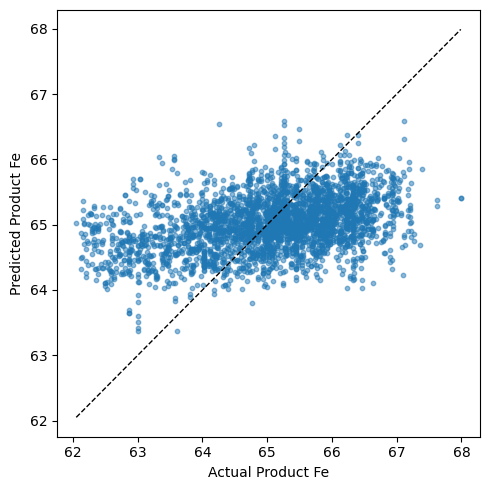

In [5]:
# --- Drop target and excluded features from df_full ---
df_model = df.drop(['Product Fe', 'Product Si', 'Feed Fe', 'Feed Si'], axis=1)

X = df_model.values
y = df['Product Fe'].values

# Standardise inputs and split(PLS is sensitive to scale)
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# --- Fit PLS (choose n_components via cross-validation below) ---
n_components = 6
pls = PLSRegression(n_components=n_components)
pls.fit(X_train, y_train)
y_pred = pls.predict(X_test).ravel()
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"PLS ({n_components} components)  |  R² = {r2:.4f}  |  RMSE = {rmse:.4f}")

# --- Parity plot ---
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, y_pred, s=10, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'k--', linewidth=1)
ax.set_xlabel('Actual Product Fe')
ax.set_ylabel('Predicted Product Fe')
plt.tight_layout()
plt.show()

# --- Project X into PLS latent space ---
T = pls.transform(X_scaled)

Perform clustering using k-means clustering.

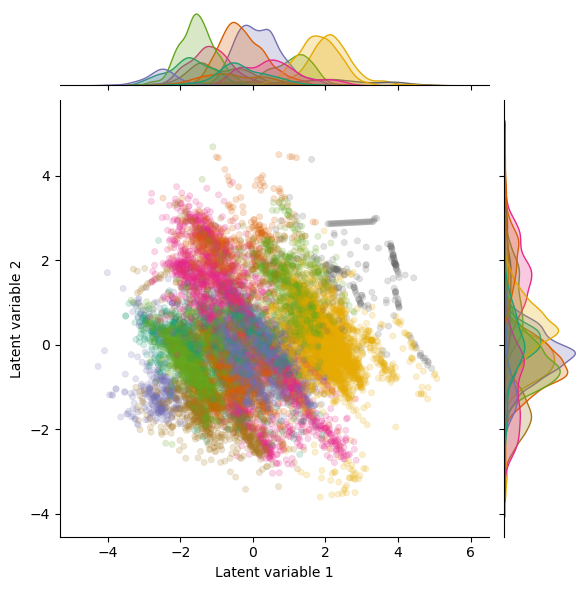

In [6]:
n_clusters = 15
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
pls_labels = kmeans.fit_predict(T)

plot_data = pd.DataFrame({'Latent variable 1': T[:, 0], 'Latent variable 2': T[:, 1], 'Cluster': pls_labels})
sns.jointplot(data=plot_data, x='Latent variable 1', y='Latent variable 2', hue='Cluster', palette='Dark2', 
              alpha=0.2, s=20, edgecolor=None, legend=False)
plt.show()

Plot each feature as a time series coloured according to cluster label.

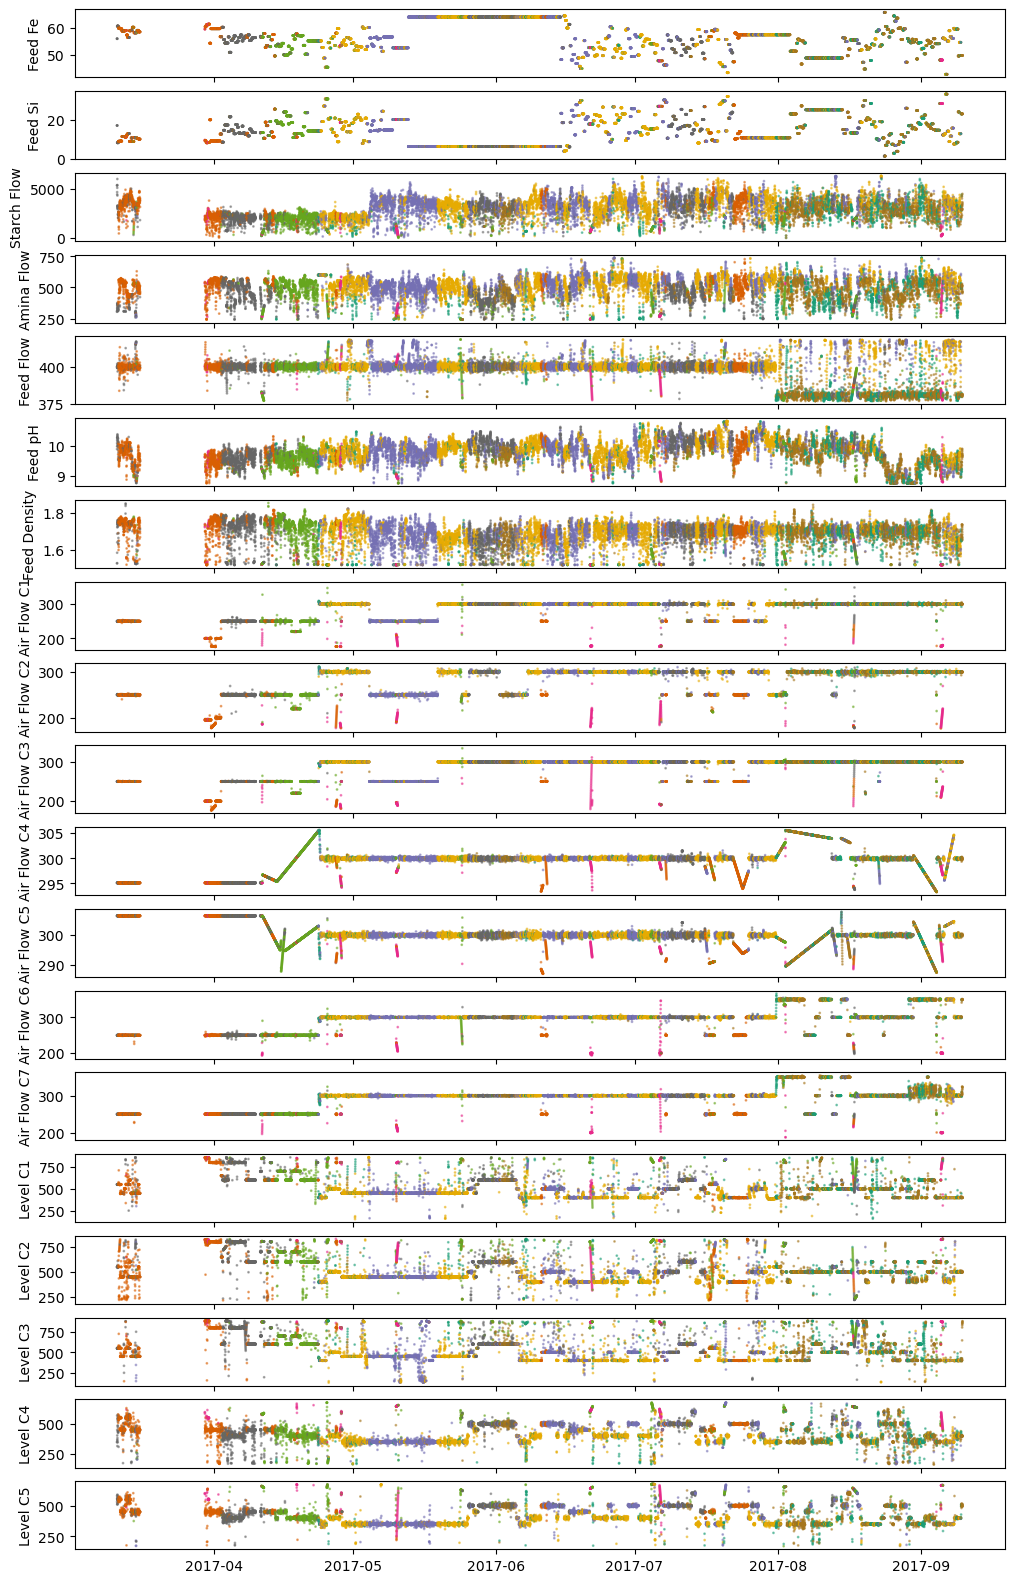

In [7]:
fig, ax = plt.subplots(19,1, figsize=(12, 20), sharex=True)
for (ax, col) in zip(ax.flatten(), df.columns):
    ax.scatter(df.index, df[col], c = pls_labels, s=1, cmap = 'Dark2', alpha = 0.5)
    ax.set_ylabel(col)   

Let's try to reduce the number of transitions by combining clusters together.

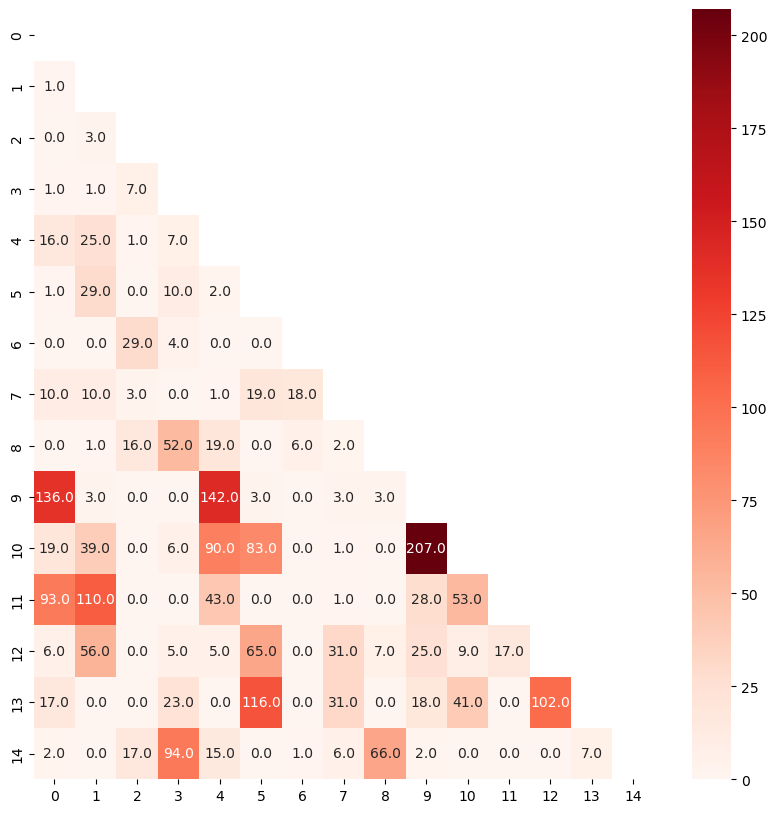

In [8]:
cluster_metric = pd.DataFrame({'Cluster t_{k}': pls_labels[:-1], 
                               'Cluster t_{k+1}': pls_labels[1:]})
cm = confusion_matrix(cluster_metric['Cluster t_{k}'], 
                      cluster_metric['Cluster t_{k+1}']) + 0.
cm += cm.T
cm[np.triu_indices_from(cm)] = np.nan

plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Reds')
plt.show()

Join clusters together where the transitions exceed a specific threshold (in this case, 100).

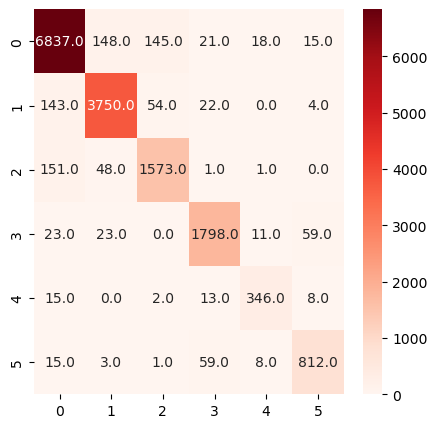

In [9]:
join = [(0,4,6,7,9,10), (5,12,13), (1,11), (3,14), (2,), (8,)]
cluster_mapping = {}
for new_label, group in enumerate(join):
    for old_label in group:
        cluster_mapping[old_label] = new_label
pls_labels_joined = np.array([cluster_mapping.get(k) for k in pls_labels])

cluster_metric_joined = pd.DataFrame({'Cluster t_{k}': pls_labels_joined[:-1], 
                                      'Cluster t_{k+1}': pls_labels_joined[1:]})
cm = confusion_matrix(cluster_metric_joined['Cluster t_{k}'], 
                      cluster_metric_joined['Cluster t_{k+1}']) + 0.


plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt='.1f', cmap='Reds')
plt.show()

C:\Users\tmlouw\AppData\Local\Temp\ipykernel_42328\1687847462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['ordered_cluster_label'], y=df['Product Fe'], ax=ax, palette='Dark2')


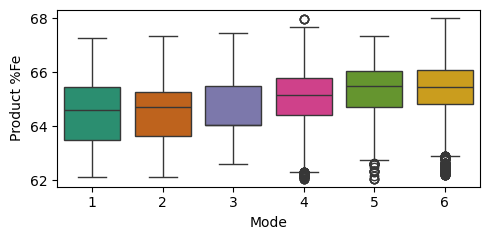

In [10]:
# Compute mean Product Fe per cluster label
means = pd.Series(df['Product Fe']).groupby(pls_labels_joined).mean()
label_order_map = {label: i+1 for i, label in enumerate(means.sort_values().index.tolist())}
df['ordered_cluster_label'] = [label_order_map[l] for l in pls_labels_joined]

fig, ax = plt.subplots(figsize=(5, 2.5))
sns.boxplot(x=df['ordered_cluster_label'], y=df['Product Fe'], ax=ax, palette='Dark2')
ax.set_xlabel('Mode')
ax.set_ylabel('Product %Fe')
plt.tight_layout()
plt.show()

# 3. Mode labelling
Perform SHAP analysis to describe individual modes

In [11]:
# Train basic LightGBM classifier
lgb_classifier = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    verbose=-1  # Suppress warnings
)

y_pred = lgb_classifier.fit(df_model, df['ordered_cluster_label'])
y_pred = lgb_classifier.predict(df_model)
print(accuracy_score(df['ordered_cluster_label'], y_pred))

0.994109623015873


In [12]:
# Initialize the SHAP explainer for the gradient boosting classifier
explainer = shap.TreeExplainer(lgb_classifier)
shap_values = explainer.shap_values(df_model)

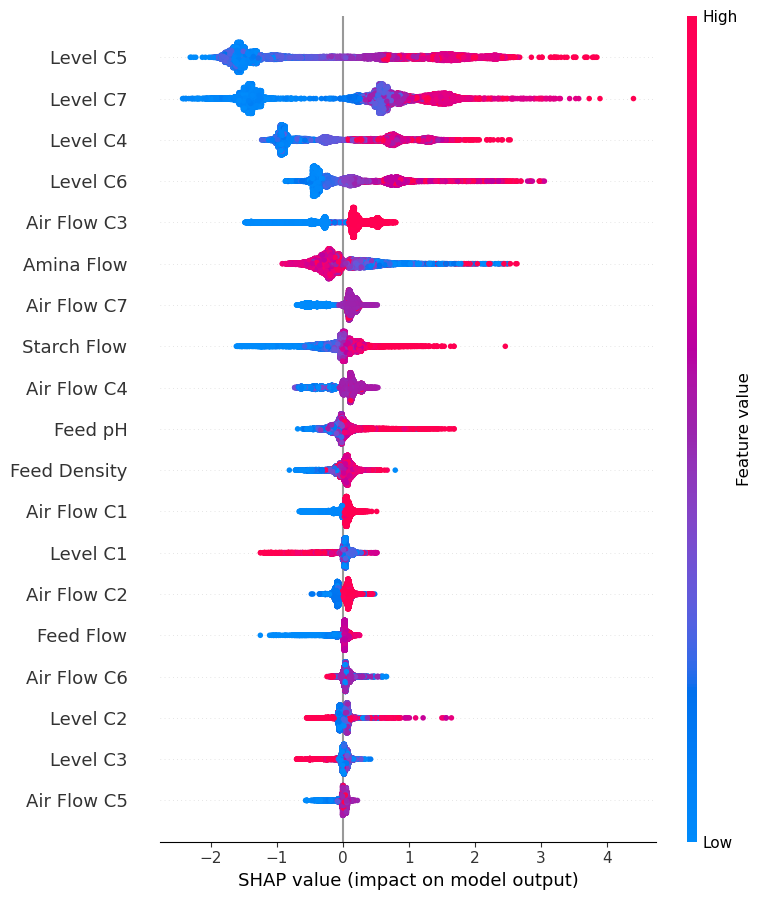

In [15]:
c = 0
shap.summary_plot(shap_values[:,:,c-1], df_model)

# 4. Transitions

Plot the inputs coloured according to clusters

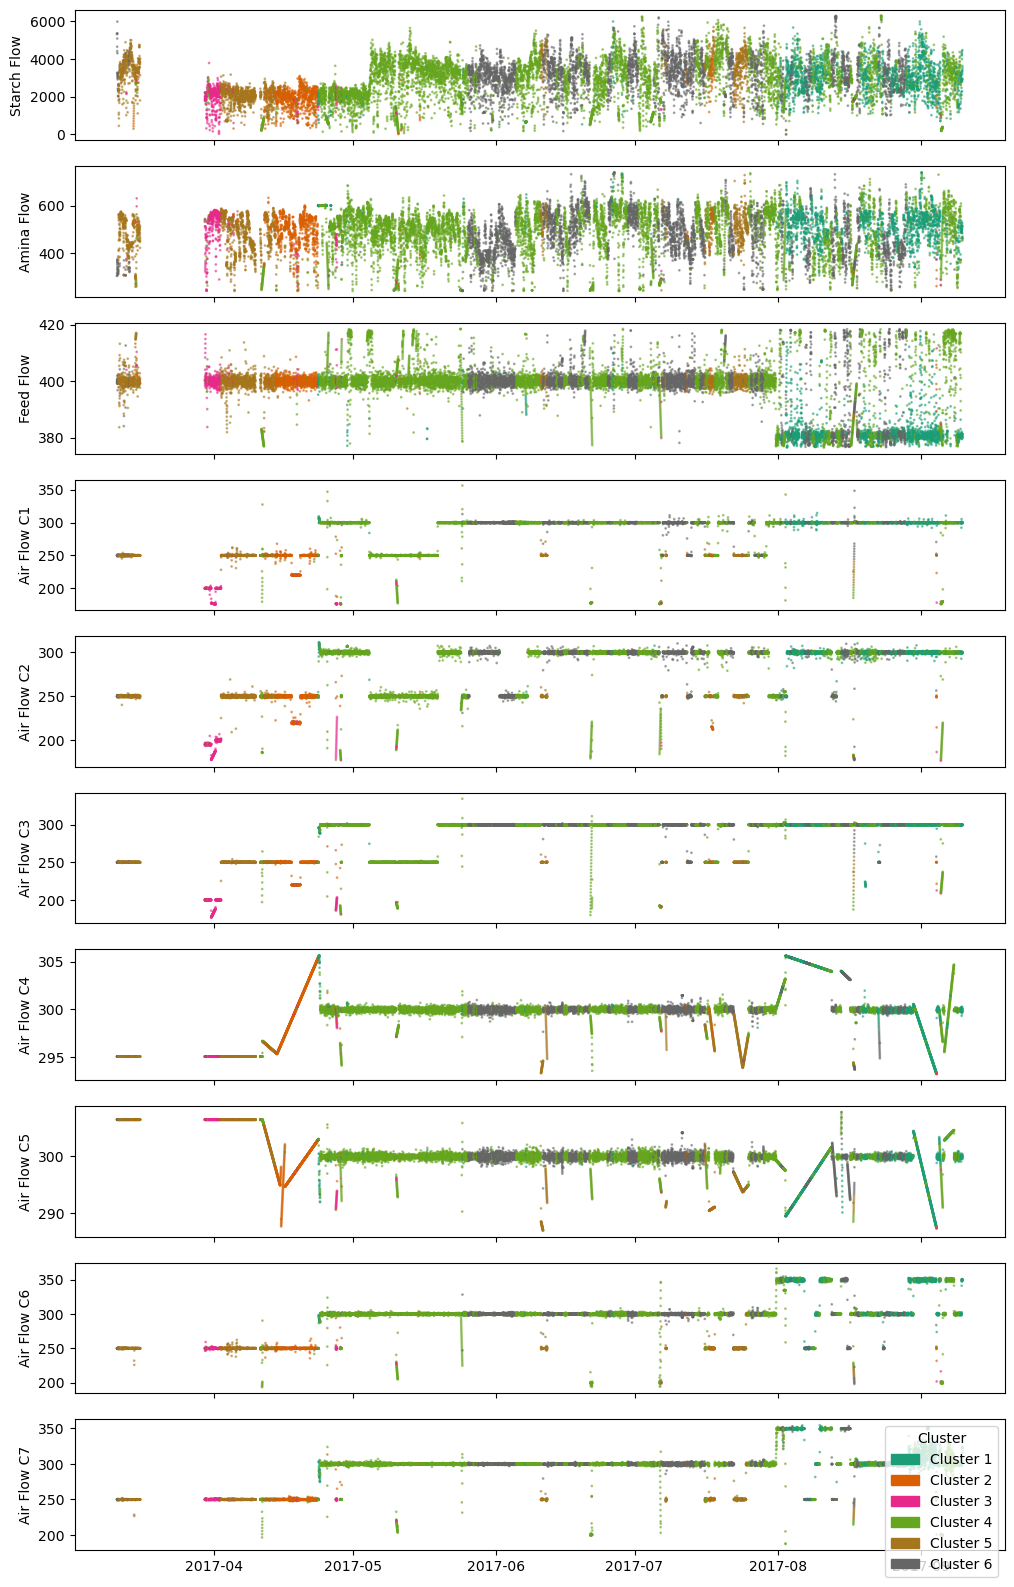

In [14]:
inputs = ['Starch Flow', 'Amina Flow', 'Feed Flow',] + \
                ['Air Flow C1', 'Air Flow C2', 'Air Flow C3', 'Air Flow C4', 'Air Flow C5', 'Air Flow C6', 'Air Flow C7']
fig, ax = plt.subplots(10,1, figsize=(12, 20), sharex=True)
for (ax, col) in zip(ax.flatten(), inputs):
    scatter = ax.scatter(df.index, df[col], c=df['ordered_cluster_label'], s=1, cmap='Dark2', alpha=0.5)
    ax.set_ylabel(col)

# Add legend for cluster labels
import matplotlib.patches as mpatches
unique_labels = np.unique(df['ordered_cluster_label'])
legend_handles = [mpatches.Patch(color=scatter.cmap(scatter.norm(l)), label=f'Cluster {l}') for l in unique_labels]
ax.legend(handles=legend_handles, loc='upper right', title='Cluster')
